In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as tkr

from DDPM import LinearNoiseScheduler
from DiT_model import DiT
from VAE import VAE

In [3]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# vae = VAE(ch = 128, latent_channels = 4).to(device)
vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse").to(device)

num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02


scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)


In [5]:
dit = DiT(d_model          = config["DiT"]["d_model"],
          g_channels       = config["DiT"]["g_channels"],
          grid_size        = config["DiT"]["grid_size"],
          patch_size       = config["DiT"]["patch_size"],
          timestep_emb_dim = config["DiT"]["timestep_emb_dim"],
          number_emb_dim   = config["DiT"]["number_emb_dim"],
          num_layers       = config["DiT"]["num_layers"],
          num_heads        = config["DiT"]["num_heads"])

vae.eval()
dit.eval()

# vae.load_state_dict(torch.load('vae_v2.pth', map_location = device))
dit.load_state_dict(torch.load(f'{ROOT}/DiT.pth', map_location = device))

<All keys matched successfully>

In [6]:
@torch.no_grad()
def sample(latent_grid_size: int, dit, vae, device, scheduler, number):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, 
                         torch.as_tensor(i).unsqueeze(0).to(device), 
                         torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [ ]:
n = 2000
img = sample(32, dit, vae, device, scheduler, (n - config["Stats"]["Re_Mean"])/config["Stats"]["Re_Std"])
img

In [32]:
img_np = np.array(img)
img_np = img_np[0]

x = np.linspace(0, 1, 256)
y = np.linspace(0, 1, 256)

u = (img_np[0] * config["Stats"]["U_STD"]) + config["Stats"]["U_MEAN"]
v = (img_np[1] * config["Stats"]["V_STD"]) + config["Stats"]["V_MEAN"]
p = (img_np[2] * config["Stats"]["P_STD"]) + config["Stats"]["P_MEAN"]

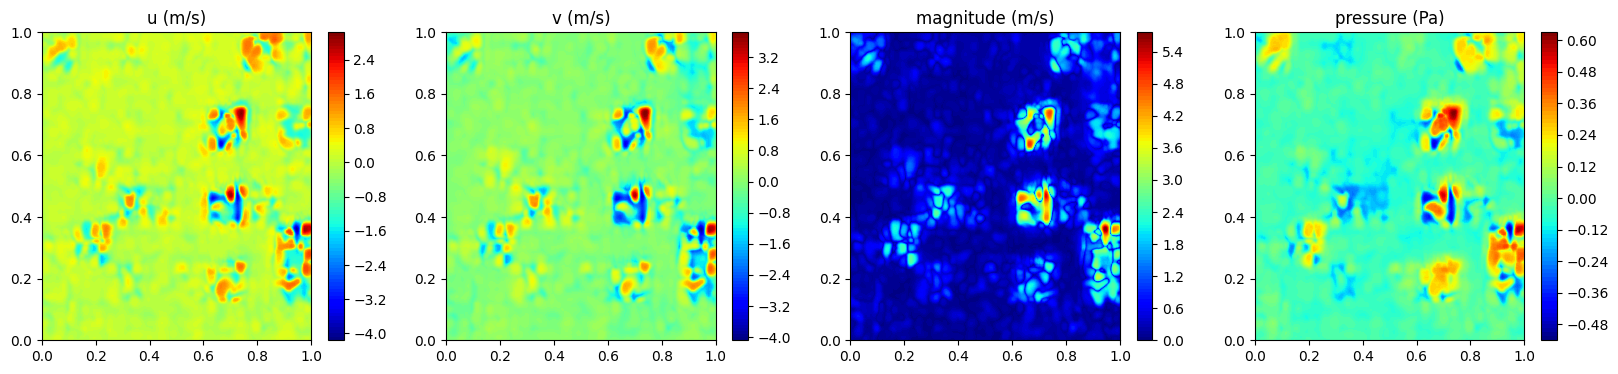

In [33]:
mag = (u**2 + v**2)**0.5
# p = img_np[:,:,2]/255

X, Y = np.meshgrid(x, y)

fig, axs = plt.subplots(1, 4, figsize = (20,4))

u_plot = axs[0].contourf(X, Y, u, levels=100, cmap = "jet")
axs[0].set_title("u (m/s)")
fig.colorbar(u_plot, ax=axs[0])

v_plot = axs[1].contourf(X, Y, v, levels=100, cmap = "jet")
axs[1].set_title("v (m/s)")
fig.colorbar(v_plot, ax=axs[1])

mag_plot = axs[2].contourf(X, Y, mag, levels=100, cmap = "jet")
axs[2].set_title("magnitude (m/s)")
fig.colorbar(mag_plot, ax=axs[2])

p_plot = axs[3].contourf(X, Y, p, levels=100, cmap = "jet")
axs[3].set_title("pressure (Pa)")
fig.colorbar(p_plot, ax=axs[3])

plt.show()

In [7]:
def predict(re_value, sample_fn, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size,
            device="cpu", plot: bool = True):
    '''
    magic
    '''
        
    # img = sample_fn(32, dit, vae, device, scheduler, re_value)
    img = sample_fn(32, dit, vae, device, scheduler, (re_value - re_mean) / re_std)

    img_np = np.array(img)

    img_np = img_np[0]


    u = (img_np[0] * u_std) + u_mean
    v = (img_np[1] * v_std) + v_mean
    p = (img_np[2] * P_std) + P_mean

    mag = np.sqrt(u**2 + v**2)

    du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
    du_dy = np.gradient(u, axis = 0)
    dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
    dv_dx = np.gradient(v, axis = 1)


    d2u_dx2 = np.gradient(du_dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, axis = 1)


    dP_dx = np.gradient(p, axis = 1)
    dP_dy = np.gradient(p, axis = 0)


    momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

    momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

    divergence = du_dx + dv_dy

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)


        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        # u
        c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        # v
        c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        # p
        c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        # mag
        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
        fig.colorbar(c3, ax=axes[3])
        axes[3].set_title("|U|")


        c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, p, divergence, momentum_res, mag

In [8]:
RE_MEAN = config["Stats"]["Re_Mean"]
RE_STD = config["Stats"]["Re_Std"]

U_MEAN = config["Stats"]["U_MEAN"]
U_STD = config["Stats"]["U_STD"]

V_MEAN = config["Stats"]["V_MEAN"]
V_STD = config["Stats"]["V_STD"]

P_MEAN = config["Stats"]["P_MEAN"]
P_STD = config["Stats"]["P_STD"]

1000it [00:54, 18.51it/s]


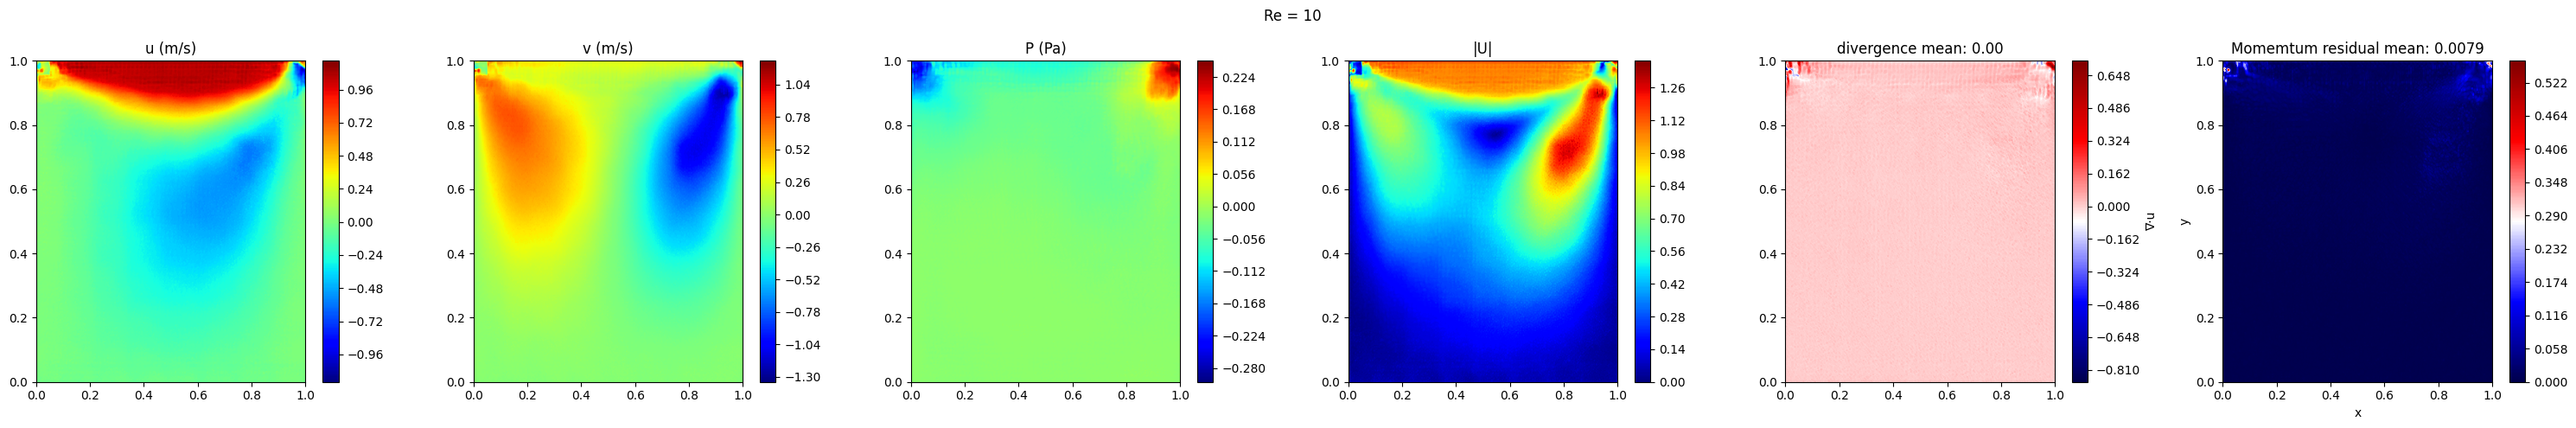

In [10]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 10, sample_fn = sample, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = 256,
                                   device = "cpu", plot = True
                                   )

In [12]:
from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

In [13]:
dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/{config['Data']['name']}")
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [71]:
uvp_grids, r, mask = next(iter(dataloader))

In [72]:
(r.item() * RE_STD) + RE_MEAN

1091.3

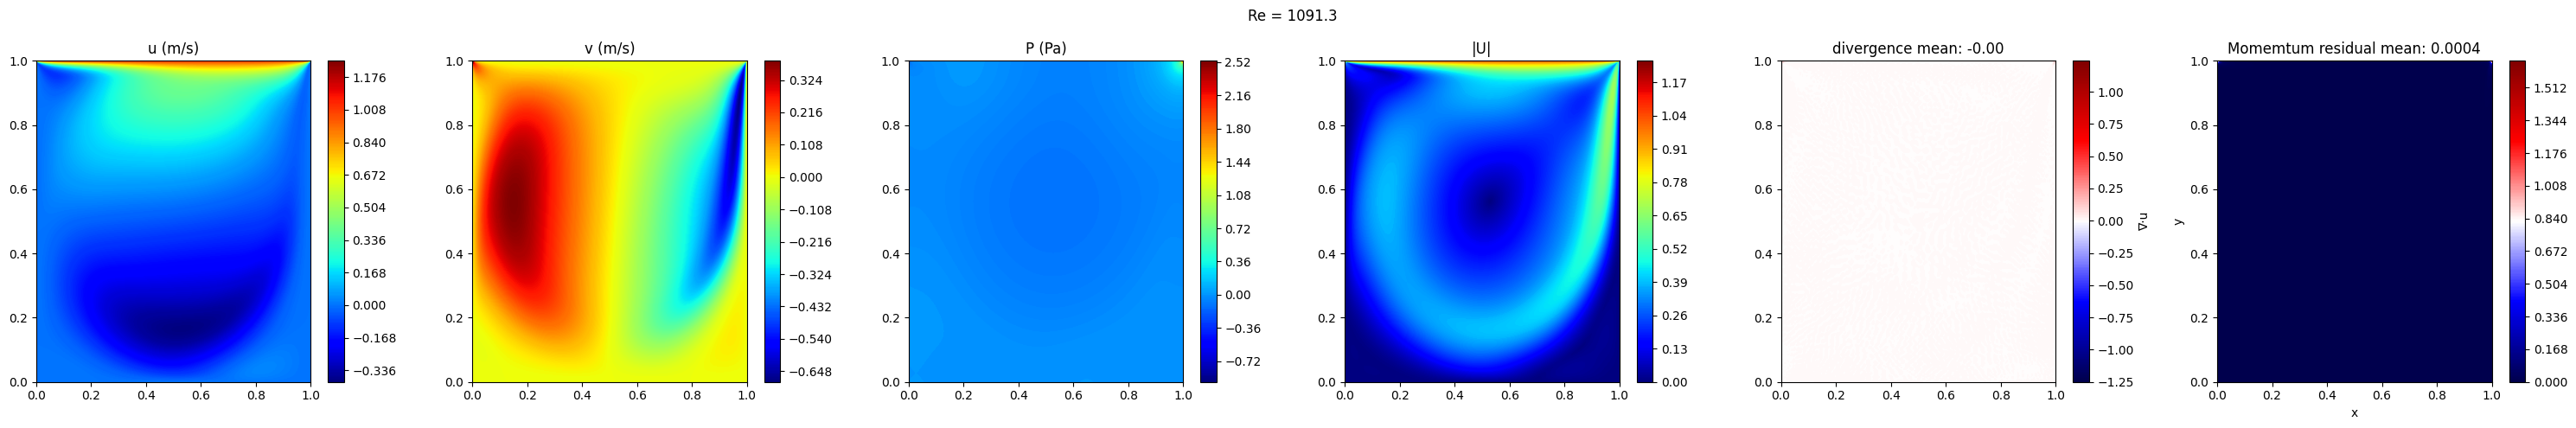

In [73]:
uvp_grid = uvp_grids[0]
re_value = (r.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()

In [ ]:
mu, logvar = vae.encode(uvp_grids)
recon = vae.decode(mu)

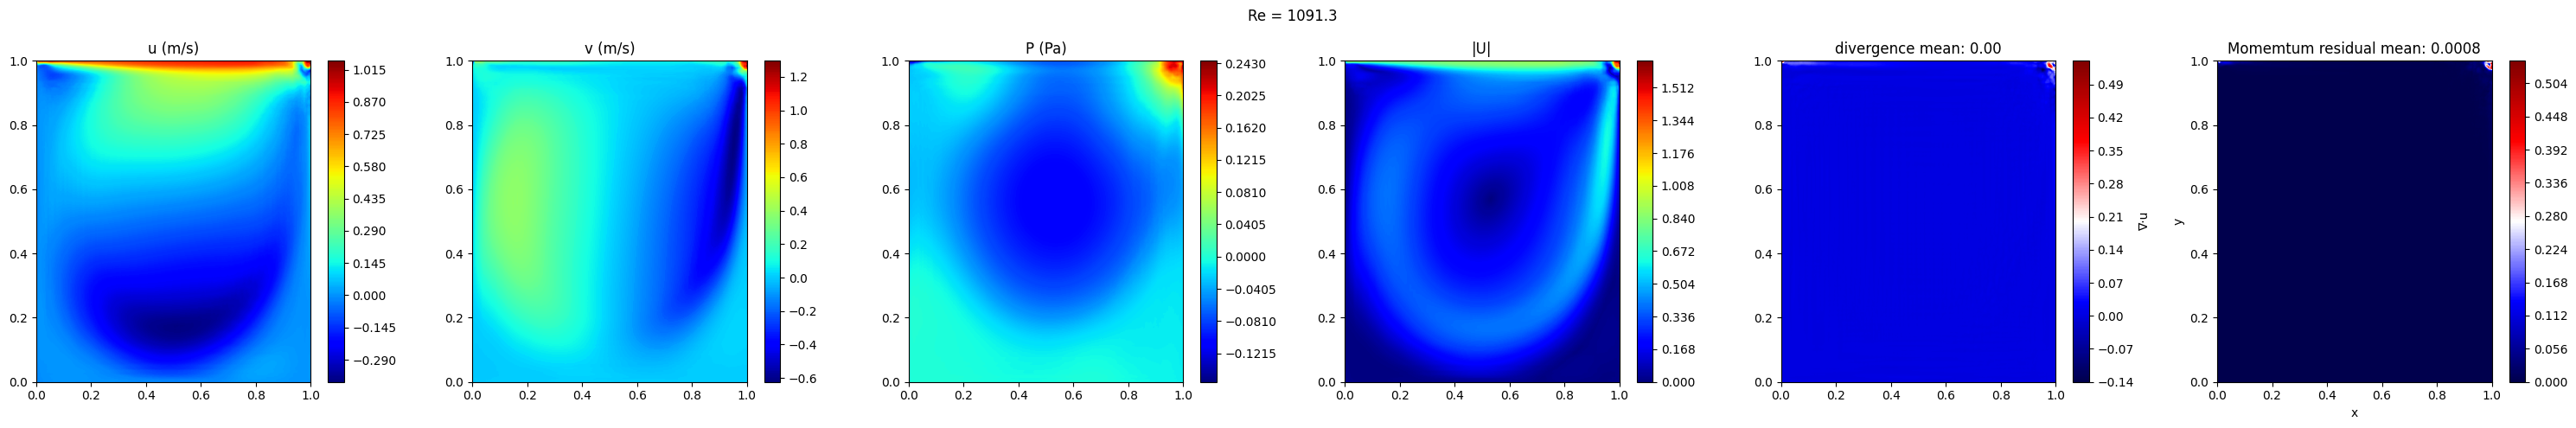

In [76]:
uvp_grid = recon[0]
re_value = (r.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()

In [14]:
# pick one actual training example
images, numbers, mask = next(iter(dataloader))
true_number = numbers[0].item()      # already normalized, matches training distribution

with torch.no_grad():
    mu, logvar = vae.encode(images.to(device))
    z_true = mu[0:1]                 # ground truth latent, no reparam noise

# sample from scratch using that exact training Re
img = sample(32, dit, vae, device, scheduler, true_number)

# compare img (decoded generation) against vae.decode(z_true) (ground truth)

1000it [00:45, 22.12it/s]


In [ ]:
vae.decode(z_true)

torch.Size([4, 32, 32])

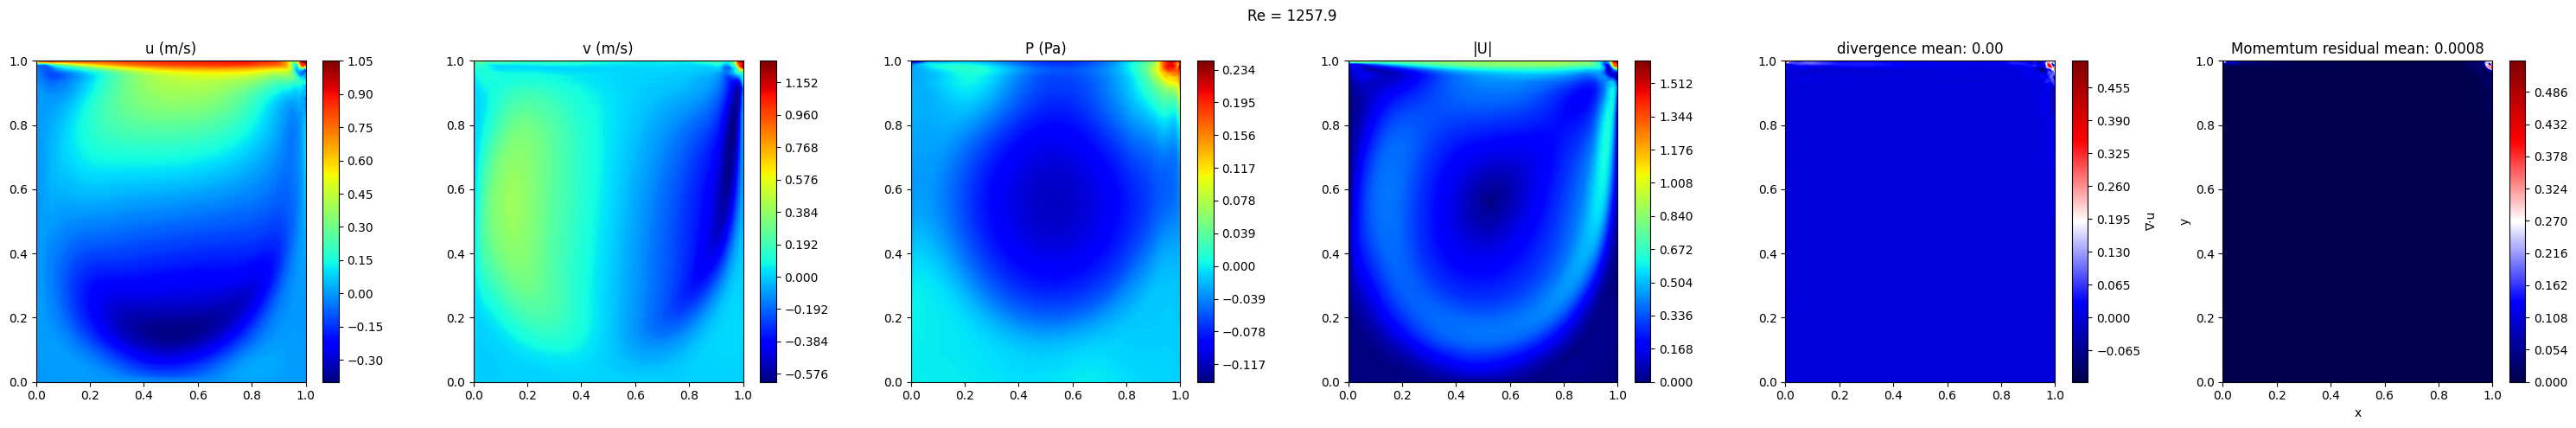

In [19]:
uvp_grid = vae.decode(z_true)[0]
re_value = (numbers.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()